# Классификация

Кольчурин Андрей Николавеич

студент физико-математического института,

направления радиофизика,

группы ФМ/О РФЗ-1-2022 НБ

# Импорт библиотек и загрузка данных

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')



In [32]:
# Загрузка данных
df = pd.read_csv('cirrhosis1.csv')


In [33]:
display(df.head())

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,2.0,0.0,21464,0.0,1.0,1.0,1.0,2.0,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,0.0,0.0,20617,0.0,0.0,1.0,1.0,0.0,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,2.0,0.0,25594,1.0,0.0,0.0,0.0,1.0,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,2.0,0.0,19994,0.0,0.0,1.0,1.0,1.0,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,1.0,1.0,13918,0.0,0.0,1.0,1.0,0.0,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [34]:
df.shape

(312, 20)

In [35]:
# Основная информация о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             312 non-null    int64  
 1   N_Days         312 non-null    int64  
 2   Status         312 non-null    float64
 3   Drug           312 non-null    float64
 4   Age            312 non-null    int64  
 5   Sex            312 non-null    float64
 6   Ascites        312 non-null    float64
 7   Hepatomegaly   312 non-null    float64
 8   Spiders        312 non-null    float64
 9   Edema          312 non-null    float64
 10  Bilirubin      312 non-null    float64
 11  Cholesterol    312 non-null    float64
 12  Albumin        312 non-null    float64
 13  Copper         312 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  312 non-null    float64
 17  Platelets      312 non-null    float64
 18  Prothrombi

In [36]:
# Статистические характеристики
display(df.describe())

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,156.500000,2006.362179,0.862179,0.493590,18269.442308,0.115385,0.076923,0.512821,0.288462,0.221154,3.256090,364.125000,3.520000,97.490385,1982.655769,122.556346,123.096154,261.871795,10.725641,3.032051
std,90.210864,1123.280843,0.960764,0.500762,3864.805407,0.319999,0.266897,0.500639,0.453775,0.549014,4.530315,221.923027,0.419892,85.360932,2140.388824,56.699525,62.122820,94.993533,1.004323,0.877880
min,1.000000,41.000000,0.000000,0.000000,9598.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,78.750000,1191.000000,0.000000,0.000000,15427.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800000,255.750000,3.310000,41.750000,871.500000,80.600000,87.000000,200.000000,10.000000,2.000000
50%,156.500000,1839.500000,0.000000,0.000000,18187.500000,0.000000,0.000000,1.000000,0.000000,0.000000,1.350000,309.500000,3.550000,73.000000,1259.000000,114.700000,108.000000,257.000000,10.600000,3.000000
75%,234.250000,2697.250000,2.000000,1.000000,20715.000000,0.000000,0.000000,1.000000,1.000000,0.000000,3.425000,392.250000,3.800000,123.000000,1980.000000,151.900000,145.250000,322.000000,11.100000,4.000000
max,312.000000,4556.000000,2.000000,1.000000,28650.000000,1.000000,1.000000,1.000000,1.000000,2.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,563.000000,17.100000,4.000000


In [37]:
# Проверка пропущенных значений
print(df.isnull().sum())

ID               0
N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64


# Визуализация данных

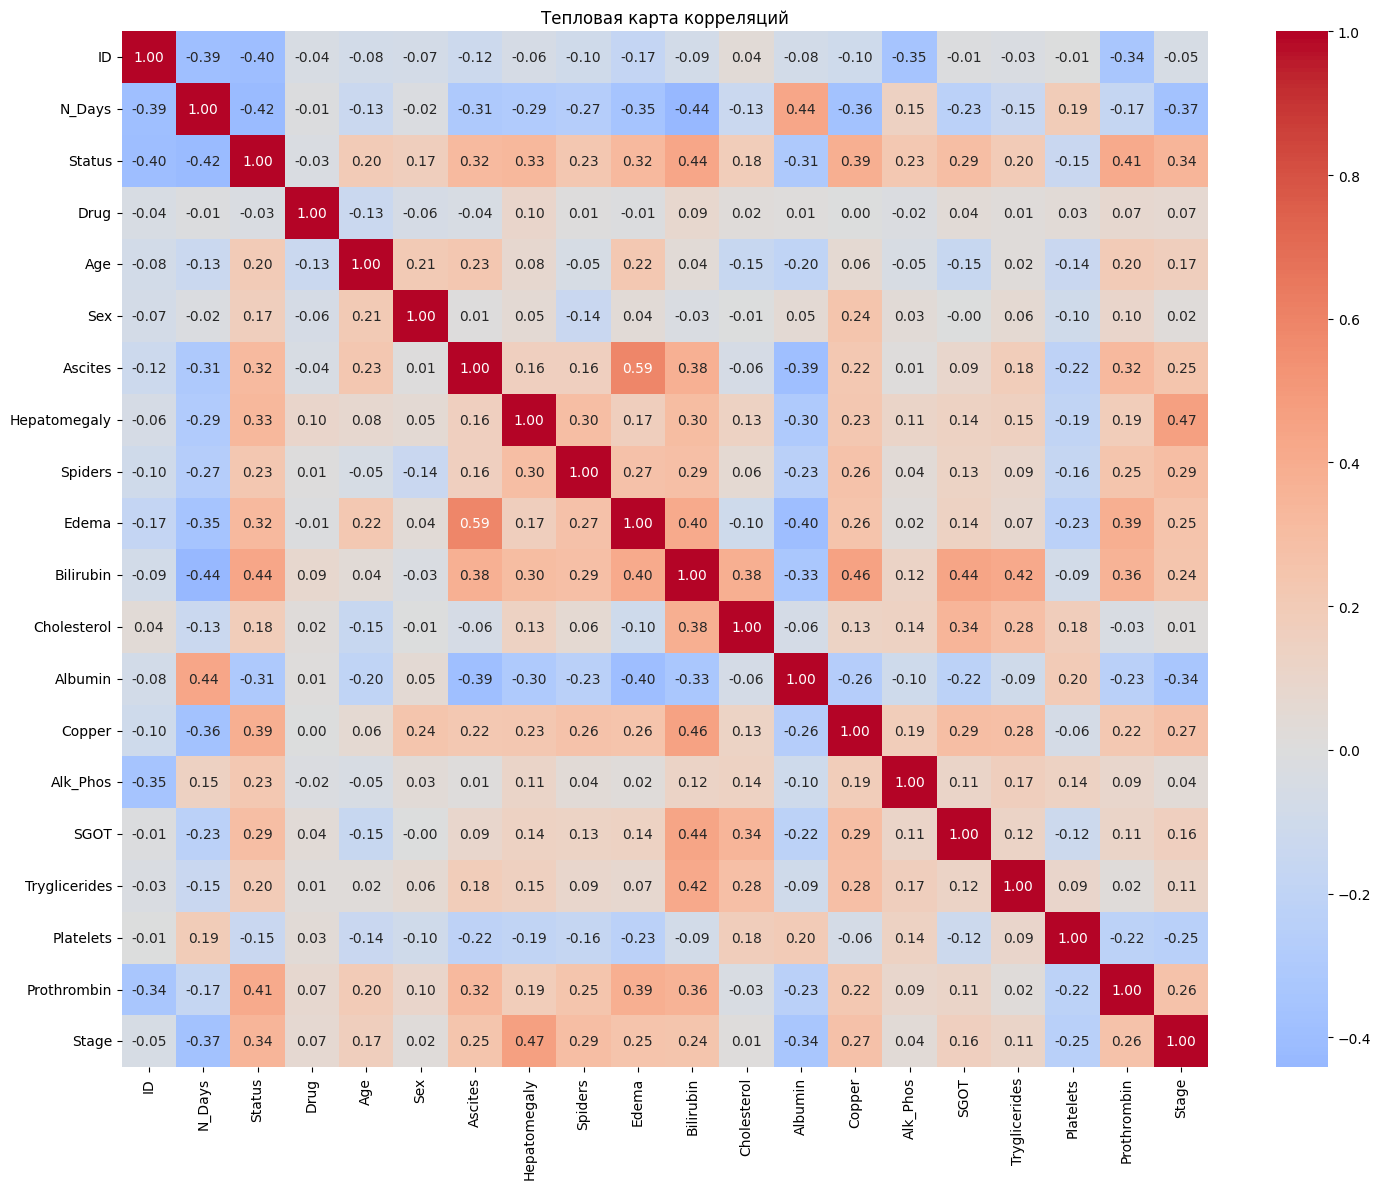

In [38]:
# Тепловая карта корреляций
plt.figure(figsize=(15, 12))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

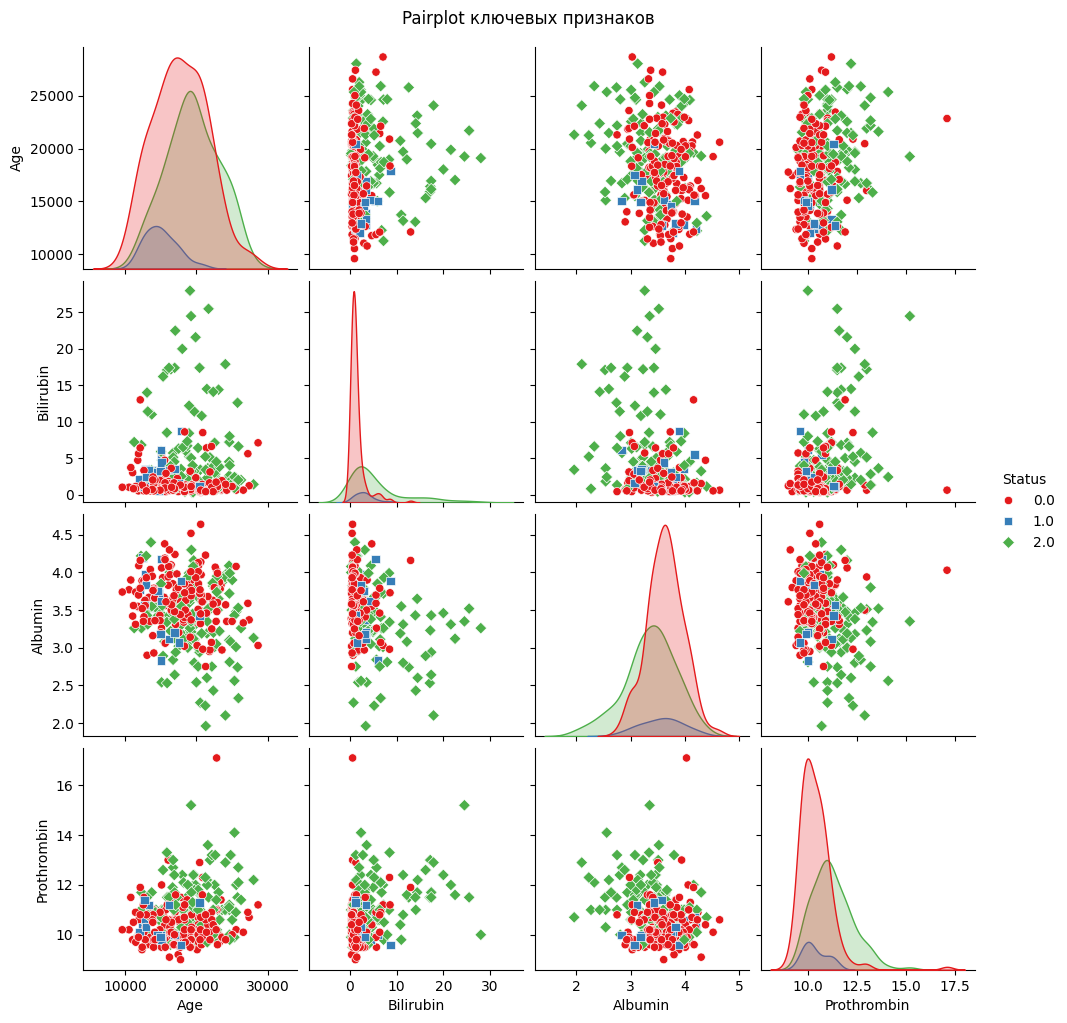

In [39]:
# Pairplot для ключевых переменных
features_to_plot = ['Age', 'Bilirubin', 'Albumin', 'Prothrombin', 'Status']
pair_df = df[features_to_plot].dropna()
sns.pairplot(pair_df, hue='Status', palette='Set1', markers=['o', 's', 'D'])
plt.suptitle('Pairplot ключевых признаков', y=1.02)
plt.show()

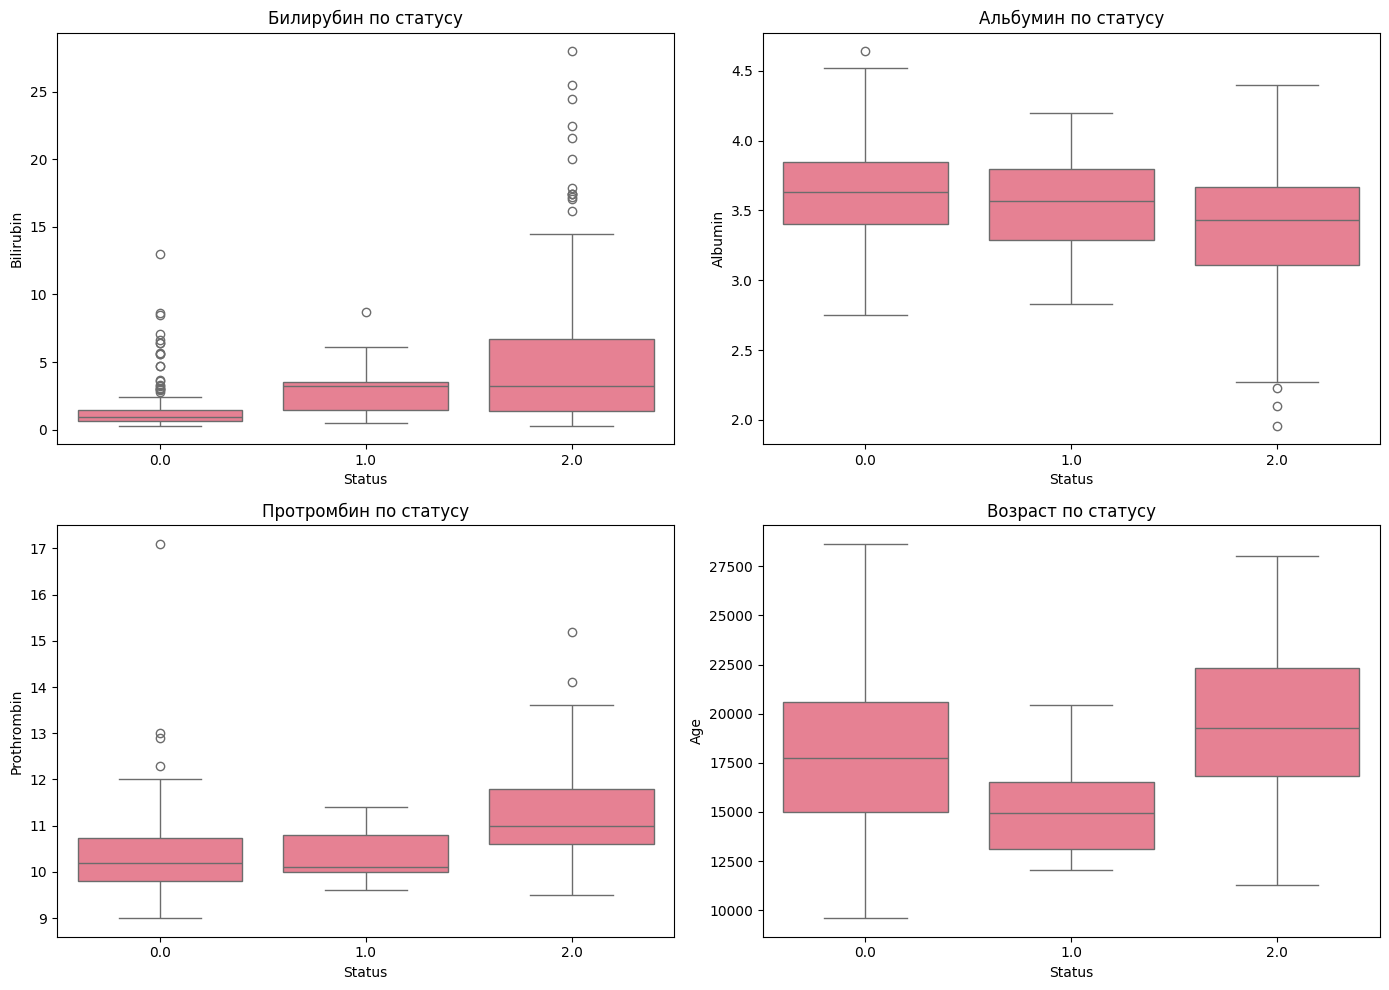

In [40]:
# Распределение важных признаков по статусу
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(x='Status', y='Bilirubin', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Билирубин по статусу')

sns.boxplot(x='Status', y='Albumin', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Альбумин по статусу')

sns.boxplot(x='Status', y='Prothrombin', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Протромбин по статусу')

sns.boxplot(x='Status', y='Age', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Возраст по статусу')
plt.tight_layout()
plt.show()

# Предобработка данных

In [41]:
# Подготовка данных для классификации
df_prep = df.copy()

 Определение признаков и целевой переменной.
 Предположим, что целевая переменная - Status (статус пациента)

In [42]:
X = df_prep.drop(['ID', 'Status'], axis=1, errors='ignore')
y = df_prep['Status']

In [43]:
# Стандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [44]:
print(f"Размер после предобработки: {X_scaled.shape}")
print(f"Распределение целевой переменной:\n{y.value_counts()}")

Размер после предобработки: (312, 18)
Распределение целевой переменной:
Status
0.0    168
2.0    125
1.0     19
Name: count, dtype: int64


# Разделение на обучающую и тестовую выборки

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (234, 18)
Размер тестовой выборки: (78, 18)


# Обучение и оценка моделей классификации

In [46]:
# Определение моделей
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(random_state=42)
}


In [47]:
# Результаты кросс-валидации
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Результаты 5-кратной кросс-валидации:")
print("-" * 60)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    results[name] = scores.mean()
    print(f"{name:20s}: Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

Результаты 5-кратной кросс-валидации:
------------------------------------------------------------
Logistic Regression : Accuracy = 0.7436 (+/- 0.0357)
LDA                 : Accuracy = 0.7437 (+/- 0.0294)
KNN                 : Accuracy = 0.7007 (+/- 0.0592)
Decision Tree       : Accuracy = 0.6412 (+/- 0.0227)
Naive Bayes         : Accuracy = 0.3201 (+/- 0.1067)
SVM                 : Accuracy = 0.7392 (+/- 0.0682)


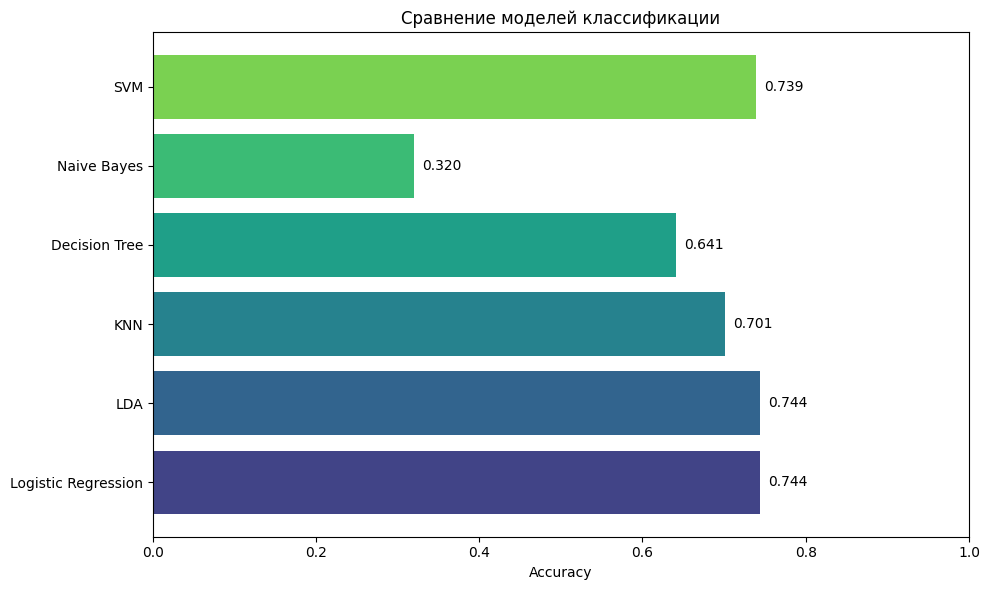

In [48]:
# Визуализация результатов
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
accuracies = list(results.values())
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(model_names)))

bars = plt.barh(model_names, accuracies, color=colors)
plt.xlabel('Accuracy')
plt.title('Сравнение моделей классификации')
plt.xlim(0, 1)

# Добавление значений на столбцы
for bar, acc in zip(bars, accuracies):
    plt.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.3f}', va='center')

plt.tight_layout()
plt.show()

# Детальная оценка лучшей модели

In [49]:
# Выбор лучшей модели по результатам кросс-валидации
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\nЛучшая модель: {best_model_name}")


Лучшая модель: LDA


In [50]:
# Обучение лучшей модели
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

In [51]:
# Метрики качества на тестовой выборке
print("\nМетрики на тестовой выборке:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Метрики на тестовой выборке:
Accuracy:  0.7436
Precision: 0.7161
Recall:    0.7436

Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.86      0.80        42
         1.0       0.00      0.00      0.00         5
         2.0       0.79      0.71      0.75        31

    accuracy                           0.74        78
   macro avg       0.51      0.52      0.52        78
weighted avg       0.72      0.74      0.73        78



Важность признаков

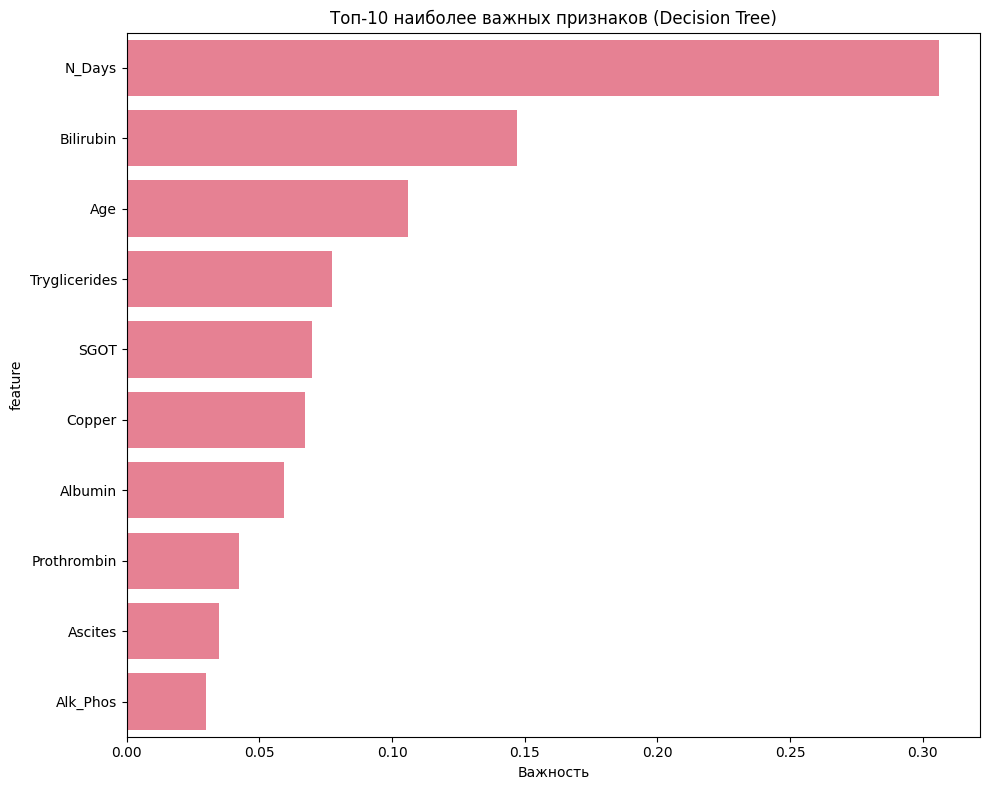


Топ-10 важных признаков:
      feature  importance
       N_Days    0.306257
    Bilirubin    0.147220
          Age    0.105890
Tryglicerides    0.077214
         SGOT    0.069981
       Copper    0.067323
      Albumin    0.059182
  Prothrombin    0.042346
      Ascites    0.034897
     Alk_Phos    0.029726


In [54]:

if 'Decision Tree' in models:
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train, y_train)

    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': dt_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
    plt.title('Топ-10 наиболее важных признаков (Decision Tree)')
    plt.xlabel('Важность')
    plt.tight_layout()
    plt.show()

    print("\nТоп-10 важных признаков:")
    print(feature_importance.head(10).to_string(index=False))

# Анализ коэффициентов

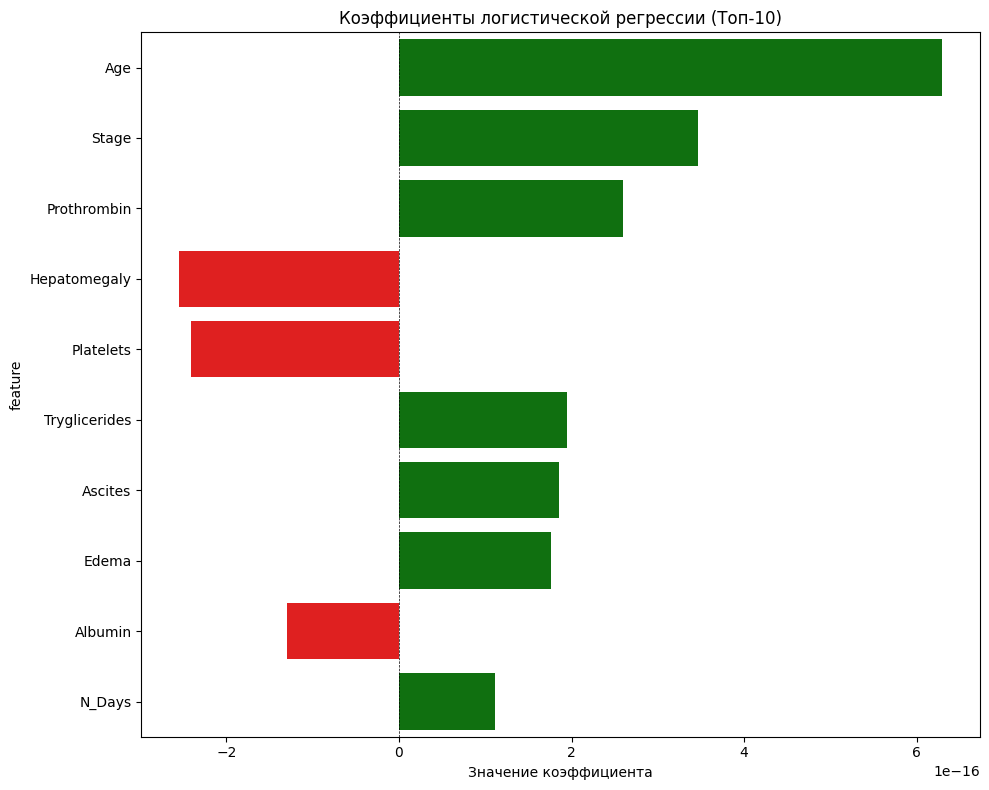

In [56]:
# Коэффициенты для Logistic Regression
if 'Logistic Regression' in models:
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train, y_train)

    if hasattr(lr_model, 'coef_') and lr_model.coef_.ndim == 2:
        coef_df = pd.DataFrame({
            'feature': X.columns,
            'coefficient': lr_model.coef_[0] if lr_model.coef_.shape[0] == 1 else lr_model.coef_.mean(axis=0)
        }).sort_values('coefficient', key=abs, ascending=False)

        plt.figure(figsize=(10, 8))
        colors = ['red' if x < 0 else 'green' for x in coef_df['coefficient'].head(10)]
        sns.barplot(x='coefficient', y='feature', data=coef_df.head(10), palette=colors)
        plt.title('Коэффициенты логистической регрессии (Топ-10)')
        plt.xlabel('Значение коэффициента')
        plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()

In [57]:
# Сводная таблица всех метрик
summary_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    summary_results.append({
        'Model': name,
        'CV Accuracy': f"{results[name]:.4f}",
        'Test Accuracy': f"{accuracy_score(y_test, y_pred):.4f}",
        'Test Precision': f"{precision_score(y_test, y_pred, average='weighted'):.4f}",
        'Test Recall': f"{recall_score(y_test, y_pred, average='weighted'):.4f}"
    })

summary_df = pd.DataFrame(summary_results)
print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
              Model CV Accuracy Test Accuracy Test Precision Test Recall
Logistic Regression      0.7436        0.7308         0.7244      0.7308
                LDA      0.7437        0.7436         0.7161      0.7436
                KNN      0.7007        0.7692         0.7331      0.7692
      Decision Tree      0.6412        0.6026         0.6168      0.6026
        Naive Bayes      0.3201        0.3590         0.7743      0.3590
                SVM      0.7392        0.7821         0.7328      0.7821


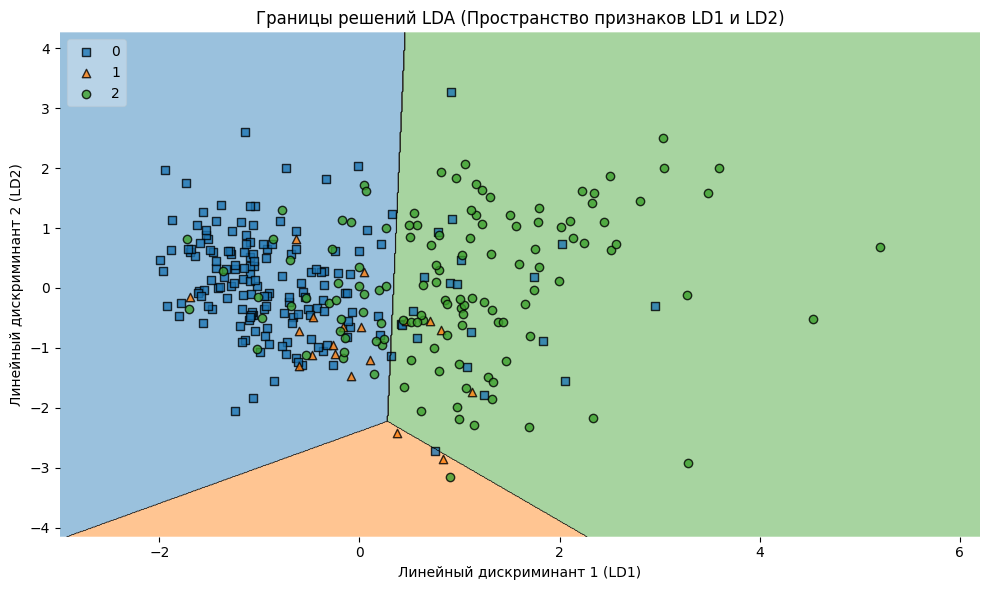

In [66]:

import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions

X = dataset.drop(['Status'], axis=1)
y = dataset["Status"].map({0.0: 0, 1.0: 1, 2.0: 2})

# Преобразование признаков с помощью LDA (сокращаем до 2-х компонент для визуализации)
sk_lda = LinearDiscriminantAnalysis(solver='svd')
X_lda = sk_lda.fit_transform(X, y)

# Разделение на обучающую и тестовую выборки (стратифицированное)
X_lda_train, X_lda_test, y_train, y_test = train_test_split(
    X_lda, y, random_state=0, stratify=y
)

# Обучение классификатора только для отрисовки границ
clf_visualizer = LinearDiscriminantAnalysis(solver='svd')
clf_visualizer.fit(X_lda_train, y_train)

# Визуализация границ решений в пространстве LDA
plt.figure(figsize=(10, 6))
plot_decision_regions(X=X_lda, y=y.values.astype(int), clf=clf_visualizer, legend=2)
plt.title('Границы решений LDA (Пространство признаков LD1 и LD2)')
plt.xlabel('Линейный дискриминант 1 (LD1)')
plt.ylabel('Линейный дискриминант 2 (LD2)')
plt.tight_layout()
plt.show()